# RoboMimic Can Closed-Loop Evaluation (MuJoCo)

This notebook evaluates the trained Liquid and Diffusion checkpoints in the actual MuJoCo / robosuite simulator for RoboMimic Can.

Because the simulator stack is available in the Python 3.12 environment, the notebook launches a helper script with `.venv312` and then loads the saved JSON results back into the notebook for analysis.

## 1. Notebook Imports and Paths

In [18]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
PY312 = ROOT / ".venv312" / "bin" / "python"
SCRIPT_PATH = ROOT / "scripts" / "eval_robomimic_can_closedloop_mujoco.py"
RESULT_PATH = ROOT / "artifacts" / "robomimic_can_closedloop_mujoco.json"

print(f"Notebook Python: {sys.executable}")
print(f"Python 3.12 helper: {PY312}")
print(f"Evaluation script: {SCRIPT_PATH}")
print(f"Result JSON: {RESULT_PATH}")

Notebook Python: /Users/ncorrell/Library/CloudStorage/OneDrive-UCB-O365/Desktop/random/liquidnets/.venv/bin/python
Python 3.12 helper: /Users/ncorrell/Library/CloudStorage/OneDrive-UCB-O365/Desktop/random/liquidnets/.venv312/bin/python
Evaluation script: /Users/ncorrell/Library/CloudStorage/OneDrive-UCB-O365/Desktop/random/liquidnets/scripts/eval_robomimic_can_closedloop_mujoco.py
Result JSON: /Users/ncorrell/Library/CloudStorage/OneDrive-UCB-O365/Desktop/random/liquidnets/artifacts/robomimic_can_closedloop_mujoco.json


## 2. Configure the Python 3.12 MuJoCo Evaluation

In [19]:
assert PY312.exists(), f"Missing Python 3.12 interpreter: {PY312}"
assert SCRIPT_PATH.exists(), f"Missing evaluation script: {SCRIPT_PATH}"

print("Ready to launch MuJoCo evaluation with Python 3.12.")
print("If needed, edit --max-episodes in the next cell.")

Ready to launch MuJoCo evaluation with Python 3.12.
If needed, edit --max-episodes in the next cell.


## 3. Run Closed-Loop Evaluation in MuJoCo

In [21]:
MAX_EPISODES = 10

cmd = [
    str(PY312),
    str(SCRIPT_PATH),
    "--max-episodes", str(MAX_EPISODES),
    "--output", str(RESULT_PATH),
]

print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True, cwd=ROOT)

with RESULT_PATH.open("r") as f:
    results = json.load(f)

print(json.dumps({
    "num_episodes": results["num_episodes"],
    "liquid": {
        "success_rate": results["liquid"]["success_rate"],
        "avg_max_reward": results["liquid"]["avg_max_reward"],
        "avg_final_reward": results["liquid"]["avg_final_reward"],
    },
    "diffusion": {
        "success_rate": results["diffusion"]["success_rate"],
        "avg_max_reward": results["diffusion"]["avg_max_reward"],
        "avg_final_reward": results["diffusion"]["avg_final_reward"],
    },
}, indent=2))

Running: /Users/ncorrell/Library/CloudStorage/OneDrive-UCB-O365/Desktop/random/liquidnets/.venv312/bin/python /Users/ncorrell/Library/CloudStorage/OneDrive-UCB-O365/Desktop/random/liquidnets/scripts/eval_robomimic_can_closedloop_mujoco.py --max-episodes 10 --output /Users/ncorrell/Library/CloudStorage/OneDrive-UCB-O365/Desktop/random/liquidnets/artifacts/robomimic_can_closedloop_mujoco.json


[robosuite WARNING] No private macro file found! (macros.py:57)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:58)
[robosuite WARNING] To setup, run: python /Users/ncorrell/Library/CloudStorage/OneDrive-UCB-O365/Desktop/random/liquidnets/.venv312/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:59)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


ROBOMIMIC WARNING(
    No private macro file found!
    It is recommended to use a private macro file
    To setup, run: python /Users/ncorrell/Library/CloudStorage/OneDrive-UCB-O365/Desktop/random/liquidnets/.venv312/lib/python3.12/site-packages/robomimic/scripts/setup_macros.py
)
Evaluating 10 validation episodes with MuJoCo / robosuite
liquid    | episode 01/10 | success=False | max_reward=0.0097 | steps=96
liquid    | episode 02/10 | success=False | max_reward=0.0024 | steps=105
liquid    | episode 03/10 | success=False | max_reward=0.0002 | steps=141
liquid    | episode 04/10 | success=False | max_reward=0.0001 | steps=130
liquid    | episode 05/10 | success=False | max_reward=0.0001 | steps=150
liquid    | episode 06/10 | success=False | max_reward=0.0004 | steps=129
liquid    | episode 07/10 | success=False | max_reward=0.0010 | steps=122
liquid    | episode 08/10 | success=False | max_reward=0.0010 | steps=103
liquid    | episode 09/10 | success=False | max_reward=0.0002 | step

## 4. Visualize Simulator Results

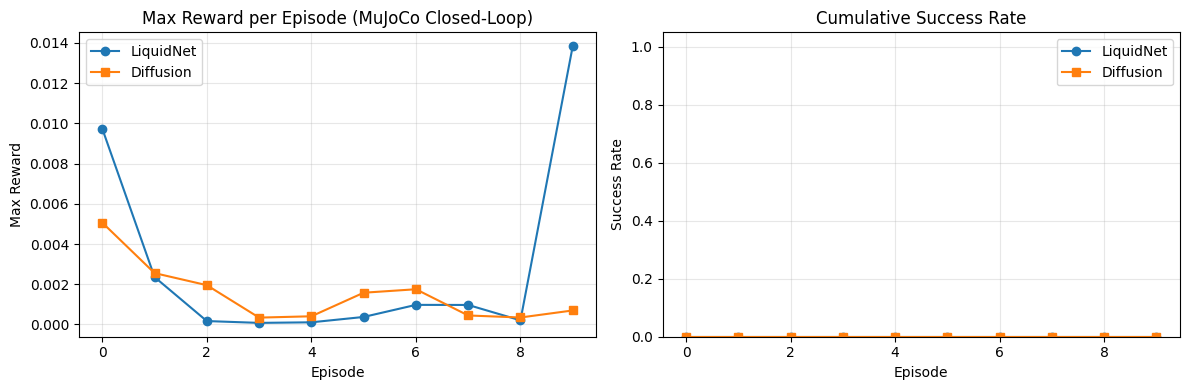

In [22]:
liquid_eps = results["liquid"]["episode_stats"]
diffusion_eps = results["diffusion"]["episode_stats"]

liquid_max = [ep["max_reward"] for ep in liquid_eps]
diffusion_max = [ep["max_reward"] for ep in diffusion_eps]
liquid_success = np.array([ep["success"] for ep in liquid_eps], dtype=float)
diffusion_success = np.array([ep["success"] for ep in diffusion_eps], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(liquid_max, marker="o", label="LiquidNet")
ax.plot(diffusion_max, marker="s", label="Diffusion")
ax.set_title("Max Reward per Episode (MuJoCo Closed-Loop)")
ax.set_xlabel("Episode")
ax.set_ylabel("Max Reward")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(np.cumsum(liquid_success) / np.arange(1, len(liquid_success) + 1), marker="o", label="LiquidNet")
ax.plot(np.cumsum(diffusion_success) / np.arange(1, len(diffusion_success) + 1), marker="s", label="Diffusion")
ax.set_title("Cumulative Success Rate")
ax.set_xlabel("Episode")
ax.set_ylabel("Success Rate")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 5. Raw Episode Tables

In [23]:
print(f"Evaluated episodes: {results['num_episodes']}")
print()
print(f"{'Model':<12} {'Success %':>10} {'Avg Max R':>12} {'Avg Final R':>12}")
print("-" * 52)
for name in ["liquid", "diffusion"]:
    r = results[name]
    print(f"{name:<12} {100 * r['success_rate']:>9.1f} {r['avg_max_reward']:>12.4f} {r['avg_final_reward']:>12.4f}")

print()
print("Liquid episodes:")
for ep in liquid_eps[:5]:
    print(ep)

print()
print("Diffusion episodes:")
for ep in diffusion_eps[:5]:
    print(ep)

Evaluated episodes: 10

Model         Success %    Avg Max R  Avg Final R
----------------------------------------------------
liquid             0.0       0.0029       0.0013
diffusion          0.0       0.0015       0.0000

Liquid episodes:
{'demo_key': 'demo_199', 'success': False, 'max_reward': 0.009732989924134794, 'final_reward': 0.00018597660533257177, 'num_steps': 96}
{'demo_key': 'demo_84', 'success': False, 'max_reward': 0.0023576967459388865, 'final_reward': 2.8583702964635196e-05, 'num_steps': 105}
{'demo_key': 'demo_28', 'success': False, 'max_reward': 0.00017096721857614574, 'final_reward': 4.0904000489394576e-05, 'num_steps': 141}
{'demo_key': 'demo_63', 'success': False, 'max_reward': 8.008685606236687e-05, 'final_reward': 2.3163154078886807e-05, 'num_steps': 130}
{'demo_key': 'demo_81', 'success': False, 'max_reward': 0.00010872869992665236, 'final_reward': 2.6402610731057765e-08, 'num_steps': 150}

Diffusion episodes:
{'demo_key': 'demo_199', 'success': False, 'max_re